## 환경 및 데이터 준비

라이브러리 설치

In [ ]:
# !apt-get update
# !apt-get install g++ openjdk-8-jdk -y
# !pip install konlpy mecab-python3
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
# !pip install gensim

In [ ]:
# !python3 -m pip install --upgrade pip
# !python3 -m pip install konlpy # Python 3.x
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) # MeCab 설치하기
# !pip install sentencepiece nltk

라이브러리 import

In [1]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from konlpy.tag import Mecab
import gensim

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.5.1+cu121


데이터 파일로드

In [2]:
# 데이터 로드 (파일 경로에 맞게 수정해주세요)
data_path = 'ChatbotData.csv'
chatbot_data = pd.read_csv(data_path)

questions = chatbot_data['Q'].tolist()
answers = chatbot_data['A'].tolist()

print(f"전체 질문 수: {len(questions)}")
print(f"전체 답변 수: {len(answers)}")

전체 질문 수: 11823
전체 답변 수: 11823


### 전처리 함수

In [3]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 1. 영문자 소문자 변환
    sentence = re.sub(r'[^a-zA-Z가-힣0-9.,?!]', ' ', sentence) # 2. 영문자, 한글, 숫자, 주요 특수문자(.,?!) 제외한 문자 제거
    return sentence

### 토큰화 및 말뭉치 구축 (Step 3)
1. KoNLPy의 Mecab을 활용하여 토큰화를 진행합니다.
2. `preprocess_sentence()`로 정제 후 토큰화를 수행합니다.
3. 소스(질문)와 타겟(답변)의 토큰 길이가 40 이하인 문장만 남깁니다.
4. 중복되는 문장은 소스와 타겟을 독립적으로 검사하여 제거하되, 쌍이 흐트러지지 않도록 `build_corpus` 함수 내에서 처리합니다.

In [4]:
mecab = Mecab()

def build_corpus(src_data, tgt_data):
    que_corpus = []
    ans_corpus = []
    
    # 중복 검사를 위한 set
    seen_src = set()
    seen_tgt = set()
    
    for src, tgt in tqdm(zip(src_data, tgt_data), total=len(src_data)):
        # 1. 정제 (전처리)
        clean_src = preprocess_sentence(src)
        clean_tgt = preprocess_sentence(tgt)
        
        # 2. 토큰화
        tok_src = mecab.morphs(clean_src)
        tok_tgt = mecab.morphs(clean_tgt)
        
        # 3. 길이 조건 검사 (예: 20 이하)
        if len(tok_src) == 0 or len(tok_tgt) == 0: 
            continue
        if len(tok_src) > 20 or len(tok_tgt) > 20: 
            continue
            
        # 4. 중복 검사 (소스와 타겟 독립적 검사)
        # 리스트 형태인 토큰을 문자열로 합쳐서 중복 여부 확인
        src_str = " ".join(tok_src)
        tgt_str = " ".join(tok_tgt)
        
        if src_str in seen_src or tgt_str in seen_tgt:
            continue # 둘 중 하나라도 중복이면 해당 쌍은 제외
            
        # 중복이 아니면 set에 추가하고 corpus에 저장
        seen_src.add(src_str)
        seen_tgt.add(tgt_str)
        
        que_corpus.append(tok_src)
        ans_corpus.append(tok_tgt)
        
    return que_corpus, ans_corpus

print("슝=3")

슝=3


- corpus 구축 실행 및 확인

In [5]:
# [cite_start]함수를 실행하여 말뭉치를 구축합니다. [cite: 59, 62]
que_corpus, ans_corpus = build_corpus(questions, answers)

print(f"구축된 질문 말뭉치 크기: {len(que_corpus)}")
print(f"구축된 답변 말뭉치 크기: {len(ans_corpus)}")

print("\n[토큰화 확인]")
print("Q:", que_corpus[0])
print("A:", ans_corpus[0])

  0%|          | 0/11823 [00:00<?, ?it/s]

구축된 질문 말뭉치 크기: 7569
구축된 답변 말뭉치 크기: 7569

[토큰화 확인]
Q: ['12', '시', '땡', '!']
A: ['하루', '가', '또', '가', '네요', '.']


### 데이터 증강 (Step 4)
- 한국어 Word2Vec 모델(ko.bin)을 활용하여 Lexical Substitution 구현
- 원본(Q-A), 증강(Aug_Q-A), 증강(Q-Aug_A) 형태로 데이터를 약 3배로 증강

#### gensim 에러

KeyedVectors.load_word2vec_format(..., binary=True) 코드가 작동했다는 것은, 

해당 파일이 파이썬의 pickle 객체로 저장된 것이 아니라 

C 언어 기반의 오리지널 Word2Vec 바이너리 포맷으로 저장된 파일이라는 뜻입니다.

In [6]:
from gensim.models import KeyedVectors
wv = KeyedVectors.load_word2vec_format('ko_converted.bin', binary=True)

print("로드 완료!")
print(len(wv))                     # 단어 수 확인
print(wv['인공지능'].shape)        # 벡터 차원 (보통 200)
print(wv.most_similar('서울', topn=5))

로드 완료!
30185
(200,)
[('서울시', 0.6911441087722778), ('서울특별시', 0.6897672414779663), ('성남', 0.6770074963569641), ('부천', 0.6612347364425659), ('인천', 0.6545476913452148)]


#### Lexical Substitution 함수 정의

In [11]:
import random
import math

# 문장 길이에 비례하여 교체할 단어 수(n_replace)를 동적으로 결정
def get_n_replace(tokens):
    # 단어 수의 약 15% 정도를 교체/삽입하되, 최소 1개, 최대 3개로 제한
    return max(1, min(3, int(len(tokens) * 0.15)))

# 1. 단어 교체 (Lexical Substitution) - topn=3으로 확장 및 n_replace 적용
def lexical_sub(tokens, wv, topn=3):
    valid_tokens = [tok for tok in tokens if tok in wv]
    if not valid_tokens:
        return None
        
    n_replace = get_n_replace(tokens)
    # 교체할 단어를 n_replace개만큼 무작위로 선택 (중복 허용 X)
    n_replace = min(n_replace, len(valid_tokens))
    selected_toks = random.sample(valid_tokens, n_replace)
    
    new_tokens = tokens.copy()
    for selected_tok in selected_toks:
        try:
            # topn 개수만큼 유사한 단어를 추출하여 그 중 하나를 무작위로 선택
            similars = wv.most_similar(selected_tok, topn=topn)
            similar_word = random.choice(similars)[0]
            
            # 선택된 단어를 새로운 단어로 교체 (첫 번째로 일치하는 것만 교체)
            idx = new_tokens.index(selected_tok)
            new_tokens[idx] = similar_word
        except:
            continue
            
    if new_tokens == tokens:
        return None
        
    return new_tokens

# 2. Random Swap (RS) - 두 단어의 위치를 바꿈
def random_swap(words):
    if len(words) < 2:
        return None
    new_words = words.copy()
    idx1, idx2 = random.sample(range(len(new_words)), 2)
    new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

# 3. Random Deletion (RD) - 확률 p로 단어 삭제
def random_deletion(words, p=0.1):
    if len(words) == 1:
        return None
        
    new_words = []
    for word in words:
        if random.random() > p:
            new_words.append(word)
            
    # 모든 단어가 삭제되면 원래 단어 중 하나를 무작위로 반환
    if len(new_words) == 0:
        return [random.choice(words)]
        
    if new_words == words:
        return None
    return new_words

# 4. Random Insertion (RI) - 임의의 단어와 유사한 단어를 무작위 위치에 삽입
def random_insertion(words, wv):
    valid_tokens = [tok for tok in words if tok in wv]
    if not valid_tokens:
        return None
        
    n_insert = get_n_replace(words)
    new_words = words.copy()
    
    for _ in range(n_insert):
        random_word = random.choice(valid_tokens)
        try:
            similar_word = wv.most_similar(random_word, topn=1)[0][0]
            random_idx = random.randint(0, len(new_words))
            new_words.insert(random_idx, similar_word)
        except:
            continue
            
    if len(new_words) == len(words):
        return None
        
    return new_words

# --- [추가할 코드] ---
# 단어 사전을 강제로 팽창시키기 위한 특수 주입 함수
def force_vocab_expansion(wv, target_size=20000):
    expansion_tokens = []
    # wv.index_to_key 는 Word2Vec이 아는 모든 단어 리스트야
    # 앞쪽의 가장 많이 쓰이는 1만~1만5천 개 단어를 무작위로 뽑아서 리스트화해
    vocab_candidates = wv.index_to_key[:target_size]
    
    # 너무 많이 넣으면 메모리가 터질 수 있으니 1만 개 정도만 잘라서 반환
    selected_expansion = random.sample(vocab_candidates, min(len(vocab_candidates), 12000))
    return selected_expansion


print("데이터 증강 기법(Lexical Sub, RS, RD, RI) 및 길이 비례 n_replace 정의 완료!")


데이터 증강 기법(Lexical Sub, RS, RD, RI) 및 길이 비례 n_replace 정의 완료!


#### 증강 실행

In [12]:
from tqdm.notebook import tqdm

aug_que_corpus = []
aug_ans_corpus = []

for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    # 0. 원본 데이터 무조건 추가
    aug_que_corpus.append(q)
    aug_ans_corpus.append(a)
    
    # --- Lexical Substitution (다양성 증가를 위해 두 번 시도) ---
    q_sub1 = lexical_sub(q, wv, topn=3)
    a_sub1 = lexical_sub(a, wv, topn=3)
    
    q_sub2 = lexical_sub(q, wv, topn=3)
    a_sub2 = lexical_sub(a, wv, topn=3)
    
    # 1. 질문만 교체
    if q_sub1:
        aug_que_corpus.append(q_sub1)
        aug_ans_corpus.append(a)
    # 2. 답변만 교체
    if a_sub1:
        aug_que_corpus.append(q)
        aug_ans_corpus.append(a_sub1)
    # 3. 둘 다 교체
    if q_sub2 and a_sub2:
        aug_que_corpus.append(q_sub2)
        aug_ans_corpus.append(a_sub2)
        
    # --- EDA 기법: Random Swap (질문에만 노이즈 적용) ---
    q_swap = random_swap(q)
    if q_swap:
        aug_que_corpus.append(q_swap)
        aug_ans_corpus.append(a) # 답변은 원본 유지
        
    # --- EDA 기법: Random Deletion (질문에만 노이즈 적용, p=0.1) ---
    q_delete = random_deletion(q, p=0.1)
    if q_delete:
        aug_que_corpus.append(q_delete)
        aug_ans_corpus.append(a)
        
    # --- EDA 기법: Random Insertion (질문에만 추가) ---
    q_insert = random_insertion(q, wv)
    if q_insert:
        aug_que_corpus.append(q_insert)
        aug_ans_corpus.append(a)

# 5. OOTV Injection: 단어 사전 규모를 2만 개로 강제 팽창시키기 위한 더미(Dummy) 데이터 삽입
expansion_words = force_vocab_expansion(wv, target_size=20000)
# 이 단어들을 100개씩 묶어서 가짜 질문(Q)으로 만들고, 답변(A)은 점(.) 하나로 때운다.
# 이렇게 하면 나중에 CustomTokenizer가 이 단어들을 전부 새 단어로 인식해서 사전에 등록해!
chunk_size = 100
for i in range(0, len(expansion_words), chunk_size):
    dummy_q = expansion_words[i:i+chunk_size]
    dummy_a = ['.'] 
    aug_que_corpus.append(dummy_q)
    aug_ans_corpus.append(dummy_a)
    
print(f"원본 말뭉치 개수 저장: {len(que_corpus)}")
print(f"증강 완료 후 전체 데이터 개수: {len(aug_que_corpus)}")


  0%|          | 0/7569 [00:00<?, ?it/s]

원본 말뭉치 개수 저장: 7569
증강 완료 후 전체 데이터 개수: 49189


### 특수 토큰 추가 및 단어 사전 구축 (Step 5)
- 타겟 데이터(답변) 양끝에 `<start>`와 `<end>` 토큰을 추가합니다.
- SentencePiece와 동일한 메서드를 가진 CustomTokenizer를 만들어 트랜스포머 모델과의 호환성을 유지합니다.

토큰 추가 및 Custom Tokenizer

In [13]:
print(f"원본 질문 말뭉치 크기: {len(que_corpus)}")
print(f"증강 후 질문 말뭉치 크기: {len(aug_que_corpus)}")
print(f"원본 답변 말뭉치 크기: {len(ans_corpus)}")
print(f"증강 후 답변 말뭉치 크기: {len(aug_ans_corpus)}")

# 확인: 증강된 데이터가 원본과 어떻게 다른지 일부 출력
for i in range(5):
    print(f"--- 샘플 {i} ---")
    print(f"Q 원본: {que_corpus[i]}")
    print(f"Q 증강: {aug_que_corpus[i*10:i*10+5]}") # 증강 비율에 따라 여러개 있을 수 있음
    print(f"A 원본: {ans_corpus[i]}")
    print(f"A 증강: {aug_ans_corpus[i*10:i*10+5]}")


원본 질문 말뭉치 크기: 7569
증강 후 질문 말뭉치 크기: 49189
원본 답변 말뭉치 크기: 7569
증강 후 답변 말뭉치 크기: 49189
--- 샘플 0 ---
Q 원본: ['12', '시', '땡', '!']
Q 증강: [['12', '시', '땡', '!'], ['12', '시', '경음', '!'], ['12', '시', '땡', '!'], ['12', '시의', '땡', '!'], ['!', '시', '땡', '12']]
A 원본: ['하루', '가', '또', '가', '네요', '.']
A 증강: [['하루', '가', '또', '가', '네요', '.'], ['하루', '가', '또', '가', '네요', '.'], ['하루', '가', '또', '가', '더군요', '.'], ['하루', '가', '설로', '가', '네요', '.'], ['하루', '가', '또', '가', '네요', '.']]
--- 샘플 1 ---
Q 원본: ['1', '지망', '학교', '떨어졌', '어']
Q 증강: [['1', '지망', '떨어졌', '학교', '어'], ['1', '지망', '학교', '학교의', '떨어졌', '어'], ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다'], ['3', '박', '4', '중순', '놀', '러', '가', '고', '싶', '다'], ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']]
A 원본: ['위로', '해', '드립니다', '.']
A 증강: [['위로', '해', '드립니다', '.'], ['위로', '해', '드립니다', '.'], ['여행', '은', '언제나', '좋', '죠', '.'], ['여행', '은', '언제나', '좋', '죠', '.'], ['여행', '은', '반드시', '좋', '죠', '.']]
--- 샘플 2 ---
Q 원본: ['3', '박', '4', '일', '놀', '러', '가', '고'

In [14]:
# 1. 타겟 데이터에 특수 토큰 추가
tgt_corpus = []
for tgt in aug_ans_corpus:
    tgt_corpus.append(["<start>"] + tgt + ["<end>"])
src_corpus = aug_que_corpus

# 2. SentencePiece를 완벽히 대체할 Custom Tokenizer 클래스 정의
from collections import Counter

class CustomTokenizer:
    def __init__(self, corpus, vocab_size=20000):
        self.pad_token = "<pad>"
        self.bos_token = "<start>"
        self.eos_token = "<end>"
        self.unk_token = "<unk>"
        
        # 기본 특수 토큰 인덱스 할당
        self.word_to_index = {self.pad_token: 0, self.bos_token: 1, self.eos_token: 2, self.unk_token: 3}
        
        # 전체 단어 빈도수 카운트
        words = []
        for sentence in corpus:
            words.extend(sentence)
            
        counter = Counter(words)
        # 자주 등장하는 단어 순서대로 사전에 추가
        for word, _ in counter.most_common(vocab_size - 4):
            if word not in self.word_to_index:
                self.word_to_index[word] = len(self.word_to_index)
        
        # 디코딩을 위한 역방향 딕셔너리
        self.index_to_word = {idx: word for word, idx in self.word_to_index.items()}
        
    def encode_as_ids(self, tokens):
        # 사전에 없으면 unk_id 반환
        return [self.word_to_index.get(word, self.unk_id()) for word in tokens]
        
    def decode_ids(self, ids):
        # 패딩, 시작, 종료 토큰을 제외하고 문자열로 복원
        return " ".join([self.index_to_word.get(i, self.unk_token) for i in ids if i not in [self.pad_id(), self.bos_id(), self.eos_id()]])
        
    def pad_id(self): return 0
    def bos_id(self): return 1
    def eos_id(self): return 2
    def unk_id(self): return 3

# 3. 전체 데이터를 합쳐서 공유 단어 사전 생성
total_corpus = src_corpus + tgt_corpus
tokenizer = CustomTokenizer(total_corpus, vocab_size=20000)
VOCAB_SIZE = len(tokenizer.word_to_index)
print(f"공유 단어 사전 크기: {VOCAB_SIZE}")

# 4. 텍스트를 정수 인덱스로 인코딩
enc_tokens = [tokenizer.encode_as_ids(src) for src in src_corpus]
dec_tokens = [tokenizer.encode_as_ids(tgt) for tgt in tgt_corpus]

공유 단어 사전 크기: 17645


패딩, 분리 및 DataLoader

In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 아까 질문/답변 최대 길이를 20으로 필터링했죠?
# 타겟 데이터는 <start>와 <end>가 추가되었으므로 MAX_LEN을 22로 설정합니다.
MAX_LEN = 22

def pad_sequences_custom(sequences, max_len, pad_value=0):
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [pad_value] * (max_len - len(seq))
        padded_sequences.append(seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# 패딩 수행
enc_ndarray = pad_sequences_custom(enc_tokens, max_len=MAX_LEN)
dec_ndarray = pad_sequences_custom(dec_tokens, max_len=MAX_LEN)

# 과적합 확인을 위한 Train / Validation 9:1 분리 (추가 루브릭)
enc_train, enc_val, dec_train, dec_val = train_test_split(
    enc_ndarray, dec_ndarray, test_size=0.1, random_state=42
)

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TensorDataset 및 DataLoader 생성
train_dataset = TensorDataset(enc_train, dec_train)
val_dataset = TensorDataset(enc_val, dec_val)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train 데이터 개수: {len(enc_train)}, Val 데이터 개수: {len(enc_val)}")
print(f"Train 배치 개수: {len(train_dataloader)}, Val 배치 개수: {len(val_dataloader)}")
print("슝=3")

Train 데이터 개수: 44270, Val 데이터 개수: 4919
Train 배치 개수: 692, Val 배치 개수: 77
슝=3


## Transfomer 구현

### Positional Encoding

In [16]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
print("슝=3")

슝=3


### 마스크 생성

In [17]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


### Multi-head Attention

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


### Position-wise Feed Forward Network

In [19]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


### Encoder Layer

In [20]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

슝=3


### Decoder Layer

In [21]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


### Encoder

In [36]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # [NEW] 최종 LayerNorm 추가
        self.norm = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        
        # [NEW] 출력 전 정규화
        out = self.norm(out)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)
print("슝=3")

슝=3


### Decoder

In [37]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # [NEW] 최종 LayerNorm 추가
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        # [NEW] 출력 전 정규화
        out = self.norm(out) 
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


### Transformer 전체 모델 조립

In [24]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


### 모델 인스턴스 생성

In [40]:
# 튜닝 1 & 2: 모델 용량 증가 및 드롭아웃 조절
n_layers = 2       # 기존 1에서 2로 층을 깊게
d_model = 512      # 기존 368에서 512로 차원 확대
n_heads = 8
d_ff = 2048        # 기존 1024에서 2048로 피드포워드 확대
dropout = 0.3      # 기존 0.2에서 0.3으로 드롭아웃 강화 (과적합 방지)

# 새로운 사이즈의 모델 인스턴스 생성
transformer = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=dropout,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)
print("업그레이드된 챗봇 모델 인스턴스 생성 완료!")

업그레이드된 챗봇 모델 인스턴스 생성 완료!


### Learning Rate Scheduler

In [41]:
class LearningRateScheduler:
    # warmup_steps를 1000으로 수정
    def __init__(self, d_model, warmup_steps=1000): 
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


### Learning Rate & Optimizer

In [42]:
# 파라미터가 완전히 바뀌었으므로 스케줄러와 옵티마이저를 새롭게 연결합니다.
learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)

optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)
print("옵티마이저 초기화 완료!")

옵티마이저 초기화 완료!


### Loss Function 정의

In [43]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


### train_step 및 val_step 정의

In [44]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 훈련 모드
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    gold = gold.to(device) # gold도 device로 이동
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    loss = loss_function(gold, predictions)
    loss.backward()
    optimizer.step()

    return loss.item()

def val_step(src, tgt, model):
    model.eval()  # 평가 모드
    with torch.no_grad(): # 기울기 계산 방지
        tgt_in = tgt[:, :-1]
        gold = tgt[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        src = src.to(device)
        tgt_in = tgt_in.to(device)
        gold = gold.to(device)
        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gold, predictions)

    return loss.item()

print("슝=3")

슝=3


### 훈련 루프 및 러닝 커브 시각화

Epoch 1 Train:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 1 완료 | Train Loss: 79.0724 | Val Loss: 7.1728



Epoch 2 Train:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 2 완료 | Train Loss: 6.5164 | Val Loss: 4.0458



Epoch 3 Train:   0%|          | 0/692 [00:00<?, ?it/s]

...

Epoch 48 완료 | Train Loss: 0.7914 | Val Loss: 0.7021



Epoch 49 Train:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 49 완료 | Train Loss: 0.7748 | Val Loss: 0.6929



Epoch 50 Train:   0%|          | 0/692 [00:00<?, ?it/s]

Epoch 50 완료 | Train Loss: 0.7574 | Val Loss: 0.6881



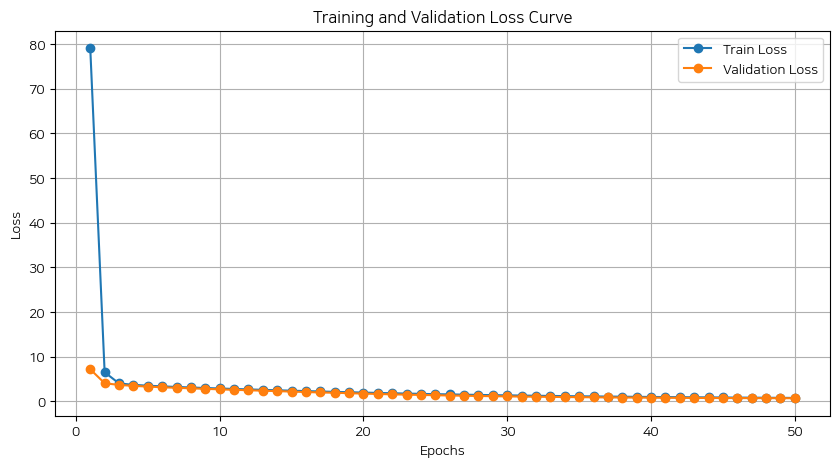

In [45]:
EPOCHS = 50 # 강화된 증강 데이터 학습을 위해 50 에폭 설정\n

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # 1. Train 
    total_train_loss = 0.0
    train_batches = len(train_dataloader)
    
    tqdm_bar = tqdm(total=train_batches, desc=f"Epoch {epoch+1} Train")
    for batch, (src, tgt) in enumerate(train_dataloader):
        step = epoch * train_batches + batch + 1
        lr = learning_rate(step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
            
        loss = train_step(src, tgt, transformer, optimizer)
        total_train_loss += loss
        
        tqdm_bar.set_postfix({"Loss": f"{loss:.4f}"})
        tqdm_bar.update(1)
    tqdm_bar.close()
    
    avg_train_loss = total_train_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # 2. Validation
    total_val_loss = 0.0
    val_batches = len(val_dataloader)
    
    for src, tgt in val_dataloader:
        loss = val_step(src, tgt, transformer)
        total_val_loss += loss
        
    avg_val_loss = total_val_loss / val_batches
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1} 완료 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

# 3. 러닝 커브 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 성능 평가

챗봇 답변 생성 함수 정의

In [46]:
# 튜닝 4: 빔 서치를 적용한 챗봇 답변 생성 함수 (버그 픽스 및 구조 개선)
def get_chat_response_beam(sentence, model, tokenizer, max_len=MAX_LEN, beam_size=3):
    model.eval()
    
    # 1. 전처리 및 형태소 분석
    clean_sentence = preprocess_sentence(sentence)
    tokens = mecab.morphs(clean_sentence)
    
    # 2. 인코딩 및 패딩
    tokens_id = tokenizer.encode_as_ids(tokens)
    padded = np.zeros((1, max_len), dtype=np.int64)
    padded[0, :min(len(tokens_id), max_len)] = tokens_id[:min(len(tokens_id), max_len)]
    src_in = torch.tensor(padded, dtype=torch.long, device=device)
    
    # 3. 빔 서치를 위한 큐 초기화. (log_prob, [단어 인덱스들]) 형태
    beams = [(0.0, [tokenizer.bos_id()])]
    
    with torch.no_grad():
        for _ in range(max_len):
            new_beams = []
            for prob, seq in beams:
                # 이미 문장이 종료된 경우 그대로 유지시켜 보강
                if seq[-1] == tokenizer.eos_id():
                    new_beams.append((prob, seq))
                    continue
                
                # 모델 예측
                dec_in = torch.tensor(seq, dtype=torch.long, device=device).unsqueeze(0)
                enc_mask, dec_enc_mask, dec_mask = generate_masks(src_in, dec_in)
                predictions, _, _, _ = model(src_in, dec_in, enc_mask, dec_enc_mask, dec_mask)
                
                # 마지막 토큰에 대한 로그 확률 계산
                logits = predictions[0, -1, :]  
                log_probs = torch.log_softmax(logits, dim=-1)
                
                # 상위 K(beam_size)개의 확률과 인덱스 추출
                topk_probs, topk_idx = torch.topk(log_probs, beam_size)
                
                for i in range(beam_size):
                    next_prob = prob + topk_probs[i].item()
                    next_seq = seq + [topk_idx[i].item()]
                    new_beams.append((next_prob, next_seq))
            
            # 누적 확률 내림차순 정렬 후 상위 beam_size 개만 업데이트
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
            
            # 모든 빔이 [EOS] 토큰을 마주쳐 종료되었으면 조기 중단
            if all(seq[-1] == tokenizer.eos_id() for _, seq in beams):
                break
                
    # 4. 가장 점수가 높은 첫 번째 후보 디코딩
    best_seq = beams[0][1]
    
    try:
        eos_idx = best_seq.index(tokenizer.eos_id())
    except ValueError:
        eos_idx = len(best_seq)
        
    final_ids = best_seq[1:eos_idx] # <start> 토큰 제외
    result = tokenizer.decode_ids(final_ids)
    return result

print("빔 서치 챗봇 함수 업데이트 완료!")

빔 서치 챗봇 함수 업데이트 완료!


프로젝트 필수 예문 테스트

In [47]:
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

print("💬 챗봇 테스트 시작!\n" + "="*30)
for sentence in test_sentences:
    response = get_chat_response_beam(sentence, transformer, tokenizer)
    print(f"Q: {sentence}")
    print(f"A: {response}\n")

💬 챗봇 테스트 시작!
Q: 지루하다, 놀러가고 싶어.
A: 다른 사람 들 이 해 보 세요 .

Q: 오늘 일찍 일어났더니 피곤하다.
A: 성공 했 길 바랍니다 .

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 아무것 도 좋 은 거 예요 .

Q: 집에 있는다는 소리야.
A: 잊 고 싶 은 방법 이 요 .



BLEU Score 정량 평가

In [48]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)

# Validation 셋의 데이터 일부(예: 100개)를 사용해 평균 BLEU 측정
total_bleu = 0.0
sample_size = 100

print(f"Validation 데이터 {sample_size}개에 대한 BLEU Score 측정 중...")

for i in range(sample_size):
    # 인코딩된 텐서를 가져와서 원래 텍스트로 복원
    src_ids = enc_val[i].tolist()
    tgt_ids = dec_val[i].tolist()
    
    # 패딩, 시작, 종료 토큰 제외하고 복원
    src_text = tokenizer.decode_ids(src_ids)
    ref_text = tokenizer.decode_ids(tgt_ids)
    
    # 복원된 소스 텍스트로 모델 예측
    candidate_text = get_chat_response_beam(src_text, transformer, tokenizer)
    
    ref_tokens = ref_text.split()
    cand_tokens = candidate_text.split()
    
    total_bleu += calculate_bleu(ref_tokens, cand_tokens)

avg_bleu = total_bleu / sample_size
print(f"\n평균 BLEU Score: {avg_bleu:.4f}")

Validation 데이터 100개에 대한 BLEU Score 측정 중...

평균 BLEU Score: 0.6684


### 어텐션 맵 시각화 및 테스트

어텐션 맵 시각화 테스트
Q: 지루하다, 놀러가고 싶어.
A: 다른 사람 들 이 해 보 세요 .



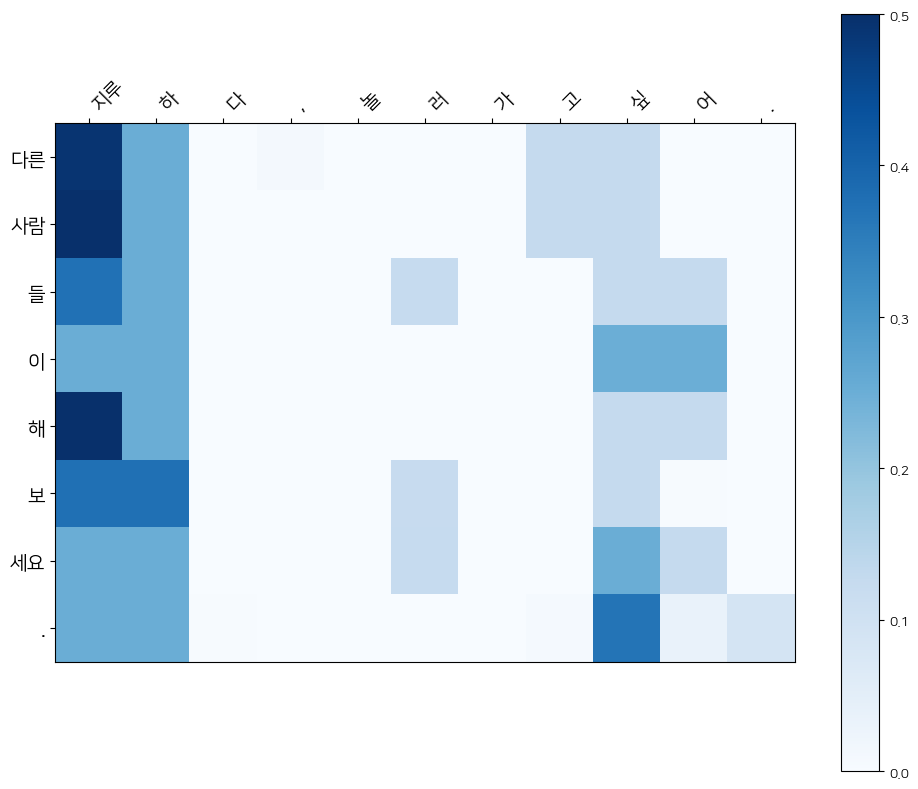

Q: 오늘 일찍 일어났더니 피곤하다.
A: 성공 했 길 바랍니다 .



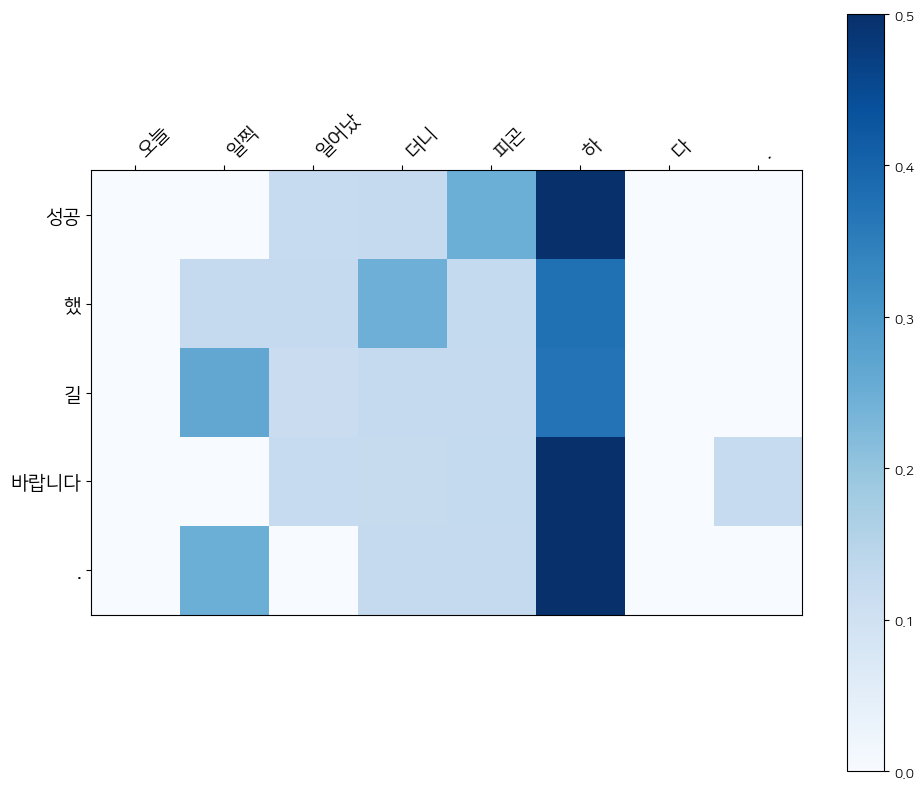

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 아무것 도 좋 은 거 예요 .



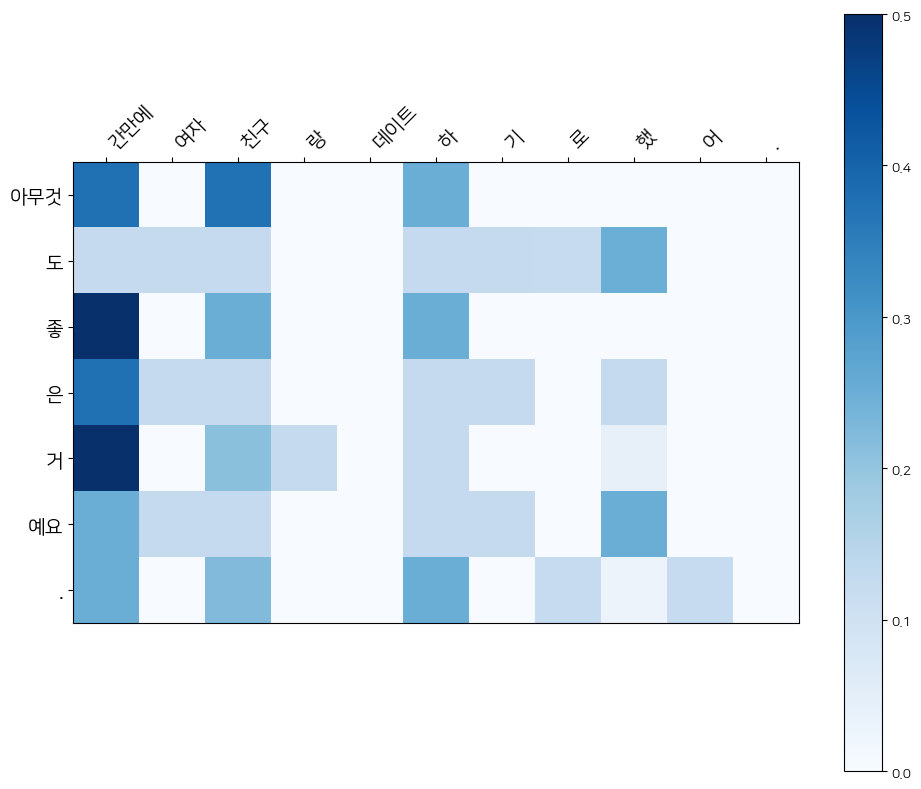

Q: 집에 있는다는 소리야.
A: 잊 고 싶 은 방법 이 요 .



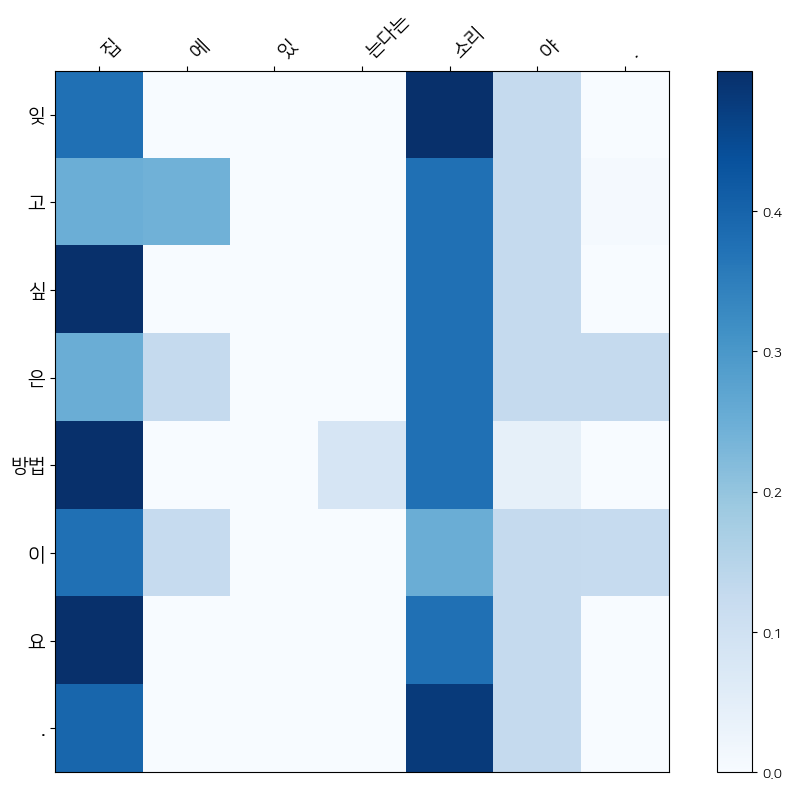

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import matplotlib as mpl
import matplotlib.font_manager as fm

# 시스템 나눔 폰트 강제 적용 (캐시 무시)
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
nanum_fonts = [font for font in font_list if 'Nanum' in font]
if nanum_fonts:
    fm.fontManager.addfont(nanum_fonts[0])
    plt.rcParams['font.family'] = fm.FontProperties(fname=nanum_fonts[0]).get_name()
else:
    print("경고: 시스템 폰트에서 나눔고딕을 찾지 못했습니다.")
plt.rcParams['axes.unicode_minus'] = False

def evaluate_and_plot_attention(sentence, model, tokenizer, max_len=MAX_LEN):
    model.eval()
    
    # 1. 전처리 및 형태소 분석
    clean_sentence = preprocess_sentence(sentence)
    tokens = mecab.morphs(clean_sentence)
    
    # 2. 인코딩 및 패딩
    tokens_id = tokenizer.encode_as_ids(tokens)
    padded_src = np.zeros((1, max_len), dtype=np.int64)
    padded_src[0, :min(len(tokens_id), max_len)] = tokens_id[:min(len(tokens_id), max_len)]
    src_in = torch.tensor(padded_src, dtype=torch.long, device=device)
    
    # 3. Decoder 입력 초기화 (<start> 토큰)
    dec_in = torch.tensor([[tokenizer.bos_id()]], dtype=torch.long, device=device)
    
    result_tokens = []
    attentions_list = []
    
    with torch.no_grad():
        for i in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_in, dec_in)
            predictions, enc_attns, dec_attns, dec_enc_attns = model(src_in, dec_in, enc_mask, dec_enc_mask, dec_mask)
            
            # 마지막 단어에 대한 예측
            predictions = predictions[:, -1:, :]
            predicted_id = torch.argmax(predictions, axis=-1)
            
            if predicted_id[0].item() == tokenizer.eos_id():
                break
                
            result_tokens.append(predicted_id[0].item())
            dec_in = torch.cat([dec_in, predicted_id], dim=-1)
            
            # 마지막 레이어의 디코더-인코더 어텐션을 저장 (모든 헤드의 평균)
            # dec_enc_attns[-1]: [batch_size, num_heads, tgt_len, src_len]
            step_attn = dec_enc_attns[-1][0, :, -1, :len(tokens_id)].mean(dim=0)
            attentions_list.append(step_attn.cpu().numpy())
            
    result = tokenizer.decode_ids(result_tokens)
    print(f"A: {result}\n")

    
    # 4. 어텐션 맵 시각화 (디자인 개선)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1)
    
    attention_matrix = np.array(attentions_list) # [tgt_len, src_len]
    
    # 컬러맵을 Blues로 지정하여 깔끔하게 표시
    cax = ax.matshow(attention_matrix, cmap='Blues')
    
    # 틱 간격과 위치 지정
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(result_tokens)))
    
    # [NEW] x축의 눈금을 위로 올리고 기울기(rotation)를 줘서 글씨 겹침 방지
    ax.tick_params(axis="x", bottom=False, top=True, labelbottom=False, labeltop=True)
    ax.set_xticklabels(tokens, fontdict={'fontsize': 14}, rotation=45, ha='left')
    
    # 세로축 라벨 설정 (생성된 단어 인덱스를 실제 단어로 변환)
    result_words = []
    for t_id in result_tokens:
        result_words.append(tokenizer.index_to_word.get(t_id, tokenizer.unk_token))
        
    ax.set_yticklabels(result_words, fontdict={'fontsize': 14})
    
    fig.colorbar(cax)
    plt.tight_layout() # 잘리는 부분 깔끔하게 정돈
    plt.show()

print(f"어텐션 맵 시각화 테스트\n" + "="*30)

for sentence in test_sentences:
    print(f"Q: {sentence}")
    evaluate_and_plot_attention(sentence, transformer, tokenizer)
